# Bragg-edge imaging with ODIN

This notebook illustrates how to convert recorded events on the ODIN detector to a single wavelength spectrum,
revealing a Bragg edge in the data.
WFM mode was used in the chopper cascade.

## Loading dataset

> Loader is not part of ``essimaging`` since McStas dataset format is not stabilized yet.

In [ ]:
import scipp as sc
import sciline as sl
import pathlib

from odin_mcstas_helper import (
    McStasManualResolution,
    load_choppers,
    PLAIN_GRAPH,
    load_mcstas_data,
)

example_resolution = McStasManualResolution((100, 100))
# Small resolution for faster testing and documentation build.

# sample_file_path = pathlib.Path("mcstas_data/sample/")
sample_file_path = pathlib.Path("mcstas_data/sample_5e11/")

# openbeam_file_path = pathlib.Path("mcstas_data/open_beam/")
openbeam_file_path = pathlib.Path("mcstas_data/open_beam_5e11/")

file_dir_path = sample_file_path
# file_dir_path = openbeam_file_path

TOF_BIN_EDGES = sc.linspace(
    dim='tof', start=0.015345509212344533, stop=0.134581150782376, num=501, unit="s"
)


In [2]:
da = load_mcstas_data(file_dir_path, resolution=example_resolution, graph=PLAIN_GRAPH)
da

<scipp.DataArray>
Dimensions: Sizes[pixel_id:10000, ]
Coordinates:
* Ltotal                    float64              [m]  (pixel_id)  [60.5006, 60.5006, ..., 60.5006, 60.5006]
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 9998, 9999]
  position                  vector3              [m]  (pixel_id)  [(-0.12375, -0.2475, 60.5), (-0.12125, -0.2475, 60.5), ..., (0.12125, 0.2475, 60.5), (0.12375, 0.2475, 60.5)]
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
  source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 137029864),
          data=float64[counts],
          coords={'position':vector3[m], 'x':float64[m], 'y':float64[m],
                  'sim_wavelength':float64[Å], 'event_time_zero':datetime64[ns],
                  'event_time_offset':float64[s], 'Ltotal':float64[m]})

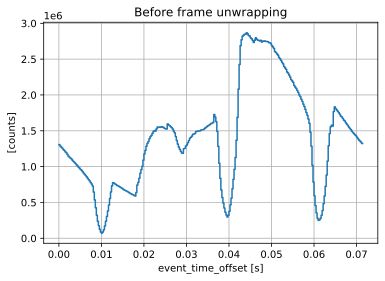

In [ ]:
# Visualize
fig_raw = (
    da.bins.concat()
    .hist(event_time_offset=300)
    .plot(title='Before frame unwrapping', grid=True)
)
fig_raw

In [4]:
import plopp as pp

pp.scatter3d(da.hist(), pos='position', cbar=True, pixel_size=0.005)

Figure(children=(HBar(children=(HTML(value=''),)), HBox(children=(VBar(children=(Toolbar(children=(ButtonTool(…

## Choppers

To accurately compute the wavelengths of the neutrons from their time-of-arrival,
we need the parameters of the choppers in the beamline.

In [ ]:
component_text_file_path = pathlib.Path(
    "mcstas_data/instrument_code/component_parameters.txt"
)
disk_choppers = load_choppers(
    file_dir_path / pathlib.Path("mccode.h5"),
    component_text_file_path,
    chopper_position_offset=sc.vector(value=[-0.026, 0, -0.025], unit='m'),
)

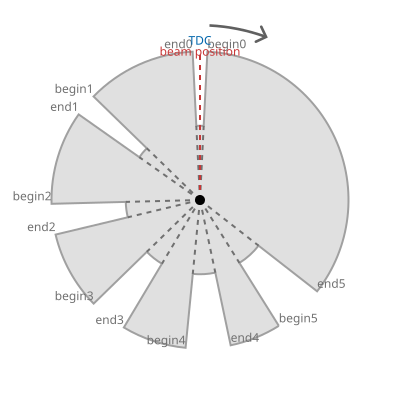

In [8]:
disk_choppers['wfmc_1']

### Check that the chopper settings make sense with a quick `tof` run

As useful sanity check is to run a basic simulation,
propagating neutrons through the chopper cascade,
using the [Tof](https://tof.readthedocs.io) package.

Plot(ax=<Axes: xlabel='Time-of-flight (us)', ylabel='Distance (m)'>, fig=<Figure size 1200x480 with 2 Axes>)

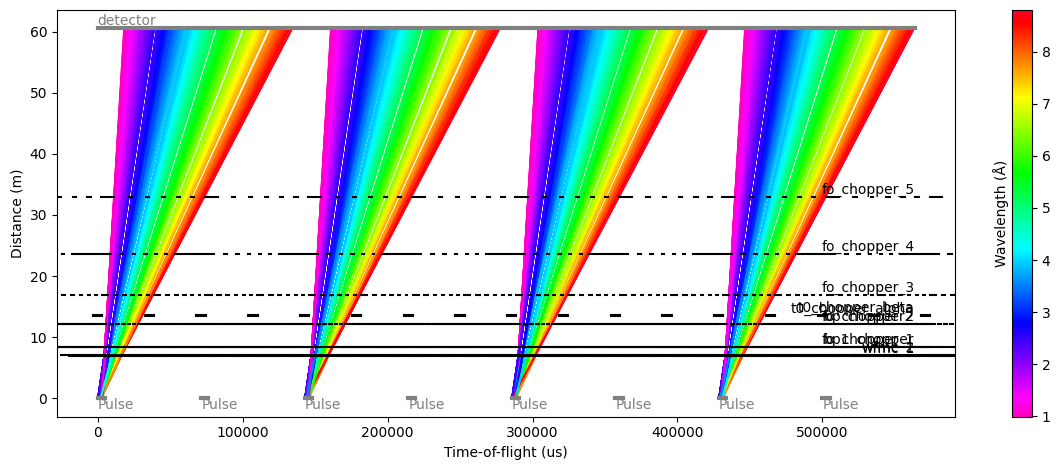

In [9]:
from ess.reduce.time_of_flight.fakes import FakeBeamline

Ltotal = da.coords['Ltotal'].mean()
ess_beamline = FakeBeamline(
    choppers=disk_choppers,
    monitors={"detector": Ltotal},
    run_length=sc.scalar(1 / 14, unit="s") * 8,
    events_per_pulse=100_000,
)

ess_beamline.model_result.plot()

We observe that the WFM choppers make 6 distinct frames at the detector,
and that the other choppers skip every other pulse to maximize wavelength coverage.

We can now compare the counts on the detector to our raw data,
to make sure they broadly resemble each other.

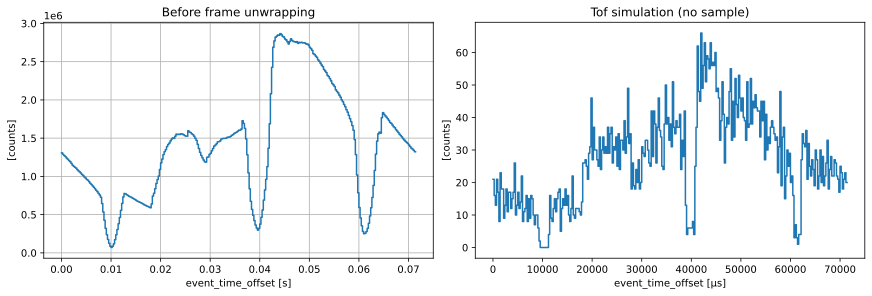

In [10]:
raw_data = ess_beamline.get_monitor("detector")[0]

# Visualize
fig_raw + raw_data.hist(event_time_offset=300).squeeze().plot(
    title='Tof simulation (no sample)'
)

## Use WFM workflow

We now set up the workflow which will convert the raw neutron arrival times to a real time-of-flight,
and thus a wavelength.

### Setting up the workflow

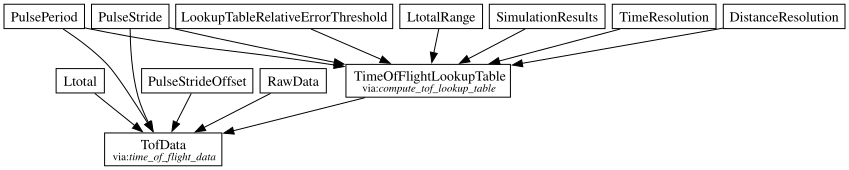

In [11]:
from ess.reduce import time_of_flight

workflow = sl.Pipeline(
    time_of_flight.providers(), params=time_of_flight.default_parameters()
)
workflow[time_of_flight.RawData] = da
workflow[time_of_flight.Ltotal] = da.coords['Ltotal']
workflow[time_of_flight.LtotalRange] = (
    sc.scalar(55.0, unit="m"),
    sc.scalar(65.0, unit="m"),
)
workflow[time_of_flight.PulseStride] = 2  # Need for pulse-skipping
workflow[time_of_flight.SimulationResults] = time_of_flight.simulate_beamline(
    choppers=disk_choppers, neutrons=2_000_000
)

workflow.visualize(time_of_flight.TofData)

### Inspect the lookup table

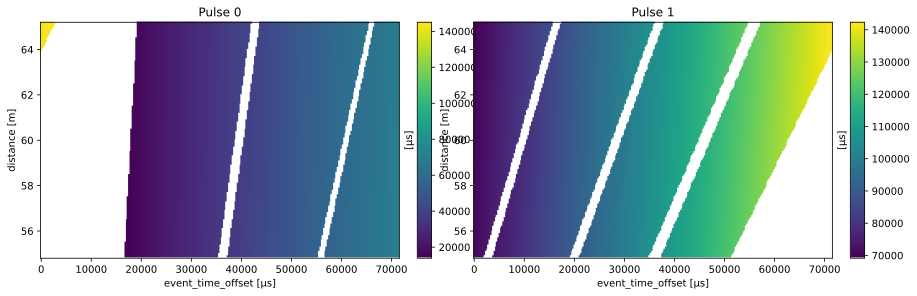

In [12]:
table = workflow.compute(time_of_flight.TimeOfFlightLookupTable).squeeze()

table['pulse', 0].plot(title='Pulse 0') + table['pulse', 1].plot(title='Pulse 1')

### Compute neutron time-of-flight

In [13]:
tofs = workflow.compute(time_of_flight.TofData)
tofs

<scipp.DataArray>
Dimensions: Sizes[pixel_id:10000, ]
Coordinates:
* Ltotal                    float64              [m]  (pixel_id)  [60.5006, 60.5006, ..., 60.5006, 60.5006]
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 9998, 9999]
  position                  vector3              [m]  (pixel_id)  [(-0.12375, -0.2475, 60.5), (-0.12125, -0.2475, 60.5), ..., (0.12125, 0.2475, 60.5), (0.12375, 0.2475, 60.5)]
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
  source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 137029864),
          data=float64[counts],
          coords={'position':vector3[m], 'x':float64[m], 'y':float64[m],
                  'sim_wavelength':float64[Å], 'event_time_zero':datetime64[ns],
                  'event_time_offset':float64[s], 'Ltotal':float64[m], 'tof':float64[s]})

In [14]:
wavs = tofs.transform_coords('wavelength', graph=PLAIN_GRAPH)
wavs

<scipp.DataArray>
Dimensions: Sizes[pixel_id:10000, ]
Coordinates:
  Ltotal                    float64              [m]  (pixel_id)  [60.5006, 60.5006, ..., 60.5006, 60.5006]
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 9998, 9999]
  position                  vector3              [m]  (pixel_id)  [(-0.12375, -0.2475, 60.5), (-0.12125, -0.2475, 60.5), ..., (0.12125, 0.2475, 60.5), (0.12375, 0.2475, 60.5)]
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
  source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 137029864),
          data=float64[counts],
          coords={'position':vector3[m], 'x':float64[m], 'y':float64[m],
                  'sim_wavelength':float64[Å], 'event_time_zero':datetime64[ns],
                  'event_time_offset':float64[s], 'Ltotal':float64[m], 'tof':float64[s],
                  'wavelength':float64[Å]})

We can now compare our computed wavelengths to the true wavelengths of the neutrons in the McStas simulation:

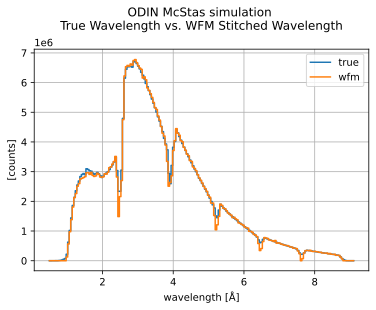

In [15]:
wavelength_bins = sc.linspace(
    'sim_wavelength', start=0.5, stop=9.1, num=201, unit='angstrom'
)
true_wavs = da.hist(sim_wavelength=wavelength_bins).rename(sim_wavelength='wavelength')

pp.plot(
    {
        'true': true_wavs.sum('pixel_id'),
        'wfm': wavs.bins.concat().hist(
            wavelength=wavelength_bins.rename(sim_wavelength='wavelength')
        ),
    },
    title="ODIN McStas simulation \nTrue Wavelength vs. WFM Stitched Wavelength\n",
    grid=True,
)

## Region of interest

Looking at the counts on the 2d detector panel,
we see that there is a central rectangular darker region,
surrounded by brighter edges.

In [16]:
true_wavs

<scipp.DataArray>
Dimensions: Sizes[pixel_id:10000, wavelength:200, ]
Coordinates:
* Ltotal                    float64              [m]  (pixel_id)  [60.5006, 60.5006, ..., 60.5006, 60.5006]
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 9998, 9999]
  position                  vector3              [m]  (pixel_id)  [(-0.12375, -0.2475, 60.5), (-0.12125, -0.2475, 60.5), ..., (0.12125, 0.2475, 60.5), (0.12375, 0.2475, 60.5)]
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
  source_position           vector3              [m]  ()  (0, 0, 0)
* wavelength                float64             [Å]  (wavelength [bin-edge])  [0.5, 0.543, ..., 9.057, 9.1]
Data:
                            float64         [counts]  (pixel_id, wavelength)  [0, 0, ..., 0, 0]  [0, 0, ..., 0, 0]

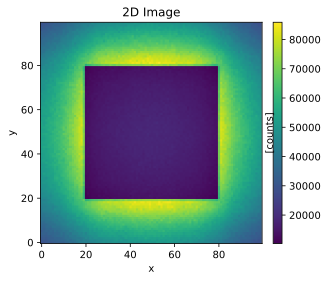

In [17]:
folded = wavs.fold(
    dim='pixel_id', sizes={'y': example_resolution[1], 'x': example_resolution[0]}
).hist()
folded.plot(aspect='equal', title='2D Image')

The dark region is where the beam was absorbed by the sample,
and this is the region of interest.
The brighter edges need to be discarded.

We crop the data using simple array slicing:

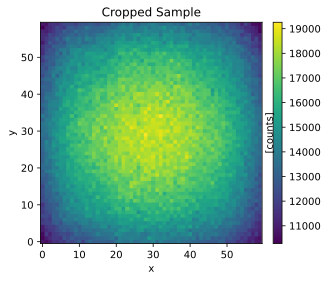

In [18]:
sel = slice(
    int(0.2 * example_resolution[0]),
    int(example_resolution[0] - 0.2 * example_resolution[0]),
    1,
)
sample_cropped = folded['y', sel]['x', sel]
sample_cropped.plot(aspect='equal', title='Cropped Sample')

## Save images as Scitiff

In [19]:
img = tofs.bin(tof=TOF_BIN_EDGES).hist()
img

<scipp.DataArray>
Dimensions: Sizes[pixel_id:10000, tof:500, ]
Coordinates:
* Ltotal                    float64              [m]  (pixel_id)  [60.5006, 60.5006, ..., 60.5006, 60.5006]
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 9998, 9999]
  position                  vector3              [m]  (pixel_id)  [(-0.12375, -0.2475, 60.5), (-0.12125, -0.2475, 60.5), ..., (0.12125, 0.2475, 60.5), (0.12375, 0.2475, 60.5)]
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
  source_position           vector3              [m]  ()  (0, 0, 0)
* tof                       float64              [s]  (tof [bin-edge])  [0.0153455, 0.015584, ..., 0.134343, 0.134581]
Data:
                            float64         [counts]  (pixel_id, tof)  [0.000436988, 0, ..., 4.19028, 1.76396]  [1.90958e-07, 0, ..., 2.30415, 1.01942]

In [20]:
from odin_mcstas_helper import as_scitiff

tof_scitiff_hist = as_scitiff(
    img, x_width=example_resolution[0], y_height=example_resolution[1]
)
tof_scitiff_hist

<scipp.Variable> (x: 100, y: 100, z: 1)    vector3              [m]  [(-0.12375, -0.2475, 60.5), (-0.12125, -0.2475, 60.5), ..., (0.12125, 0.2475, 60.5), (0.12375, 0.2475, 60.5)]

<scipp.DataArray>
Dimensions: Sizes[c:2, x:100, y:100, z:1, t:500, ]
Coordinates:
* c                          string        <no unit>  (c)  ["data", "variances"]
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
* source_position           vector3              [m]  ()  (0, 0, 0)
* tof                       float64              [s]  (t [bin-edge])  [0.0153455, 0.015584, ..., 0.134343, 0.134581]
* x                         float64              [m]  (x)  [-0.12375, -0.12125, ..., 0.12125, 0.12375]
* y                         float64              [m]  (y)  [-0.2475, -0.2425, ..., 0.2425, 0.2475]
* z                         float64              [m]  (z)  [60.5002]
Data:
                            float32         [counts]  (c, x, y, z, t)  [1.90958e-07, 0, ..., 2.30415, 1.01942]

In [21]:
import scitiff

output_file_path = file_dir_path.stem + "_mcstas.tiff"
scitiff.save_scitiff(tof_scitiff_hist, output_file_path)